Doing further analysis using the full dataset from NYC Open Data, which has many more columns.

For now, I'm looking into the 'curb_loc' column to see if income and streets being tree-lined shows any patterns. It seemed possible that in the last round of analysis, many of the trees were in parks,

In [91]:
import os
import pandas as pd
import chardet
import matplotlib.pyplot as plt
import seaborn as sns
from ipyleaflet import Map, basemaps, CircleMarker, LegendControl


In [92]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [93]:
os.getcwd()


'/workspaces/Trees-and-Income'

In [94]:
# Loading data

trees = pd.read_csv('data/raw/2015_Street_Tree_Census_-_Tree_Data_20250701.csv')

income = pd.read_csv('data/raw/income-NYC_2015.csv')

# species = pd.read_csv('data/raw/tree-species-nyc.csv')

In [95]:
# # Dealing with encoding issue in tree species data using chardet

# with open('data/raw/tree-species-nyc.csv', 'rb') as f:
#     result = chardet.detect(f.read())

# result

In [96]:
# species = pd.read_csv('data/raw/tree-species-nyc.csv', encoding=result['encoding'])

In [97]:
trees.head()

,tree_id,block_id,created_at,tree_dbh,stump_diam,curb_loc,status,health,spc_latin,spc_common,steward,guards,sidewalk,user_type,problems,root_stone,root_grate,root_other,trunk_wire,trnk_light,trnk_other,brch_light,brch_shoe,brch_other,address,postcode,zip_city,community board,borocode,borough,cncldist,st_assem,st_senate,nta,nta_name,boro_ct,state,latitude,longitude,x_sp,y_sp,council district,census tract,bin,bbl
0,180683,348711,08/27/2015,3,0,OnCurb,Alive,Fair,Acer rubrum,red maple,NaN,NaN,NoDamage,TreesCount Staff,NaN,No,No,No,No,No,No,No,No,No,108-005 70 AVENUE,11375,Forest Hills,406,4,Queens,29,28,16,QN17,Forest Hills,4073900,New York,40.723092,-73.844215,1027431.148,202756.7687,29.0,739.0,4052307.0,4.022210e+09
1,200540,315986,09/03/2015,21,0,OnCurb,Alive,Fair,Quercus palustris,pin oak,NaN,NaN,Damage,TreesCount Staff,Stones,Yes,No,No,No,No,No,No,No,No,147-074 7 AVENUE,11357,Whitestone,407,4,Queens,19,27,11,QN49,Whitestone,4097300,New York,40.794111,-73.818679,1034455.701,228644.8374,19.0,973.0,4101931.0,4.044750e+09
2,204026,218365,09/05/2015,3,0,OnCurb,Alive,Good,Gleditsia triacanthos var. inermis,honeylocust,1or2,NaN,Damage,Volunteer,NaN,No,No,No,No,No,No,No,No,No,390 MORGAN AVENUE,11211,Brooklyn,301,3,Brooklyn,34,50,18,BK90,East Williamsburg,3044900,New York,40.717581,-73.936608,1001822.831,200716.8913,34.0,449.0,3338310.0,3.028870e+09
3,204337,217969,09/05/2015,10,0,OnCurb,Alive,Good,Gleditsia triacanthos var. inermis,honeylocust,NaN,NaN,Damage,Volunteer,Stones,Yes,No,No,No,No,No,No,No,No,1027 GRAND STREET,11211,Brooklyn,301,3,Brooklyn,34,53,18,BK90,East Williamsburg,3044900,New York,40.713537,-73.934456,1002420.358,199244.2531,34.0,449.0,3338342.0,3.029250e+09
4,189565,223043,08/30/2015,21,0,OnCurb,Alive,Good,Tilia americana,American linden,NaN,NaN,Damage,Volunteer,Stones,Yes,No,No,No,No,No,No,No,No,603 6 STREET,11215,Brooklyn,306,3,Brooklyn,39,44,21,BK37,Park Slope-Gowanus,3016500,New York,40.666778,-73.975979,990913.775,182202.4260,39.0,165.0,3025654.0,3.010850e+09


In [98]:
trees.columns.tolist()

['tree_id',
 'block_id',
 'created_at',
 'tree_dbh',
 'stump_diam',
 'curb_loc',
 'status',
 'health',
 'spc_latin',
 'spc_common',
 'steward',
 'guards',
 'sidewalk',
 'user_type',
 'problems',
 'root_stone',
 'root_grate',
 'root_other',
 'trunk_wire',
 'trnk_light',
 'trnk_other',
 'brch_light',
 'brch_shoe',
 'brch_other',
 'address',
 'postcode',
 'zip_city',
 'community board',
 'borocode',
 'borough',
 'cncldist',
 'st_assem',
 'st_senate',
 'nta',
 'nta_name',
 'boro_ct',
 'state',
 'latitude',
 'longitude',
 'x_sp',
 'y_sp',
 'council district',
 'census tract',
 'bin',
 'bbl']

In [99]:
trees['curb_loc'].value_counts()

curb_loc
OnCurb            656896
OffsetFromCurb     26892
Name: count, dtype: int64

In [100]:
# Going to try dropping all the offset from curb trees and see what it does to the analysis down below.

trees = trees[trees['curb_loc'] == 'OnCurb']

In [101]:
income.head()

,GEO_ID,zipcode,HouseholdsEstimateTotal,HouseholdsMargin of ErrorTotal,HouseholdsEstimateMedian income (dollars),HouseholdsMargin of ErrorMedian income (dollars),HouseholdsEstimateMean income (dollars),HouseholdsMargin of ErrorMean income (dollars)
0,8600000US10451,10451,18140,405,26048,2140.0,40836.0,3424.0
1,8600000US10452,10452,25432,368,24790,1337.0,36083.0,1578.0
2,8600000US10453,10453,26802,409,23095,1605.0,33354.0,1416.0
3,8600000US10454,10454,12790,247,20210,1930.0,31533.0,2272.0
4,8600000US10455,10455,14023,329,23253,1598.0,32854.0,2127.0


In [102]:
# species.head()


# Cleaning trees

In [103]:
trees.columns.tolist()

['tree_id',
 'block_id',
 'created_at',
 'tree_dbh',
 'stump_diam',
 'curb_loc',
 'status',
 'health',
 'spc_latin',
 'spc_common',
 'steward',
 'guards',
 'sidewalk',
 'user_type',
 'problems',
 'root_stone',
 'root_grate',
 'root_other',
 'trunk_wire',
 'trnk_light',
 'trnk_other',
 'brch_light',
 'brch_shoe',
 'brch_other',
 'address',
 'postcode',
 'zip_city',
 'community board',
 'borocode',
 'borough',
 'cncldist',
 'st_assem',
 'st_senate',
 'nta',
 'nta_name',
 'boro_ct',
 'state',
 'latitude',
 'longitude',
 'x_sp',
 'y_sp',
 'council district',
 'census tract',
 'bin',
 'bbl']

In [104]:
# Renaming some columns

mapper = {
 'tree_dbh':'trunk_diam',
 'boroname':'borough',
 'nta_name':'neighborhood',
 'Latitude':'latitude',
 'postcode':'zipcode'
}

trees = trees.rename(columns=mapper)

trees.head()

,tree_id,block_id,created_at,trunk_diam,stump_diam,curb_loc,status,health,spc_latin,spc_common,steward,guards,sidewalk,user_type,problems,root_stone,root_grate,root_other,trunk_wire,trnk_light,trnk_other,brch_light,brch_shoe,brch_other,address,zipcode,zip_city,community board,borocode,borough,cncldist,st_assem,st_senate,nta,neighborhood,boro_ct,state,latitude,longitude,x_sp,y_sp,council district,census tract,bin,bbl
0,180683,348711,08/27/2015,3,0,OnCurb,Alive,Fair,Acer rubrum,red maple,NaN,NaN,NoDamage,TreesCount Staff,NaN,No,No,No,No,No,No,No,No,No,108-005 70 AVENUE,11375,Forest Hills,406,4,Queens,29,28,16,QN17,Forest Hills,4073900,New York,40.723092,-73.844215,1027431.148,202756.7687,29.0,739.0,4052307.0,4.022210e+09
1,200540,315986,09/03/2015,21,0,OnCurb,Alive,Fair,Quercus palustris,pin oak,NaN,NaN,Damage,TreesCount Staff,Stones,Yes,No,No,No,No,No,No,No,No,147-074 7 AVENUE,11357,Whitestone,407,4,Queens,19,27,11,QN49,Whitestone,4097300,New York,40.794111,-73.818679,1034455.701,228644.8374,19.0,973.0,4101931.0,4.044750e+09
2,204026,218365,09/05/2015,3,0,OnCurb,Alive,Good,Gleditsia triacanthos var. inermis,honeylocust,1or2,NaN,Damage,Volunteer,NaN,No,No,No,No,No,No,No,No,No,390 MORGAN AVENUE,11211,Brooklyn,301,3,Brooklyn,34,50,18,BK90,East Williamsburg,3044900,New York,40.717581,-73.936608,1001822.831,200716.8913,34.0,449.0,3338310.0,3.028870e+09
3,204337,217969,09/05/2015,10,0,OnCurb,Alive,Good,Gleditsia triacanthos var. inermis,honeylocust,NaN,NaN,Damage,Volunteer,Stones,Yes,No,No,No,No,No,No,No,No,1027 GRAND STREET,11211,Brooklyn,301,3,Brooklyn,34,53,18,BK90,East Williamsburg,3044900,New York,40.713537,-73.934456,1002420.358,199244.2531,34.0,449.0,3338342.0,3.029250e+09
4,189565,223043,08/30/2015,21,0,OnCurb,Alive,Good,Tilia americana,American linden,NaN,NaN,Damage,Volunteer,Stones,Yes,No,No,No,No,No,No,No,No,603 6 STREET,11215,Brooklyn,306,3,Brooklyn,39,44,21,BK37,Park Slope-Gowanus,3016500,New York,40.666778,-73.975979,990913.775,182202.4260,39.0,165.0,3025654.0,3.010850e+09


In [105]:
trees['state'].value_counts()

state
New York    656896
Name: count, dtype: int64

In [106]:
# cols_to_drop = [
#     'Unnamed: 0',
#     'borocode',
#     'state'
#     ]

# trees = trees.drop(cols_to_drop, axis=1)

# trees.head()

In [107]:
trees.columns.tolist()

['tree_id',
 'block_id',
 'created_at',
 'trunk_diam',
 'stump_diam',
 'curb_loc',
 'status',
 'health',
 'spc_latin',
 'spc_common',
 'steward',
 'guards',
 'sidewalk',
 'user_type',
 'problems',
 'root_stone',
 'root_grate',
 'root_other',
 'trunk_wire',
 'trnk_light',
 'trnk_other',
 'brch_light',
 'brch_shoe',
 'brch_other',
 'address',
 'zipcode',
 'zip_city',
 'community board',
 'borocode',
 'borough',
 'cncldist',
 'st_assem',
 'st_senate',
 'nta',
 'neighborhood',
 'boro_ct',
 'state',
 'latitude',
 'longitude',
 'x_sp',
 'y_sp',
 'council district',
 'census tract',
 'bin',
 'bbl']

In [108]:
cols = [
    'tree_id',
 'trunk_diam',
 'stump_diam',
 'curb_loc',
 'status',
 'health',
 'spc_latin',
 'spc_common',
 'zipcode',
 'zip_city',
 'borocode',
 'borough',
 'nta',
 'neighborhood',
 'boro_ct',
 'latitude',
 'longitude',
]

trees = trees[cols]

In [109]:
trees.shape

(656896, 17)

In [110]:
trees.info()

<class 'pandas.core.frame.DataFrame'>
Index: 656896 entries, 0 to 683787
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   tree_id       656896 non-null  int64  
 1   trunk_diam    656896 non-null  int64  
 2   stump_diam    656896 non-null  int64  
 3   curb_loc      656896 non-null  object 
 4   status        656896 non-null  object 
 5   health        626297 non-null  object 
 6   spc_latin     626293 non-null  object 
 7   spc_common    626293 non-null  object 
 8   zipcode       656896 non-null  int64  
 9   zip_city      656896 non-null  object 
 10  borocode      656896 non-null  int64  
 11  borough       656896 non-null  object 
 12  nta           656896 non-null  object 
 13  neighborhood  656896 non-null  object 
 14  boro_ct       656896 non-null  int64  
 15  latitude      656896 non-null  float64
 16  longitude     656896 non-null  float64
dtypes: float64(2), int64(6), object(9)
memory usage: 90.2

datatypes look fine

In [111]:
# The first five rows have 0 for stump_diam. Data dictionary says this variable only used when status is stump. How many stumps?

trees['stump_diam'].value_counts(normalize=True).head()

stump_diam
0    0.973923
4    0.001455
5    0.001396
3    0.001160
6    0.001111
Name: proportion, dtype: float64

3% of trees are stumps. 
Should stumps count as trees?

In [112]:
trees['status'].value_counts(normalize=True)

status
Alive    0.953420
Stump    0.026077
Dead     0.020502
Name: proportion, dtype: float64

Might want to group stump and dead together in a new column?
Stump might indicate neighborhood gets more attention than dead, which indicates neglect.

# Looking at income, cleaning if needed

In [113]:
income.head()

,GEO_ID,zipcode,HouseholdsEstimateTotal,HouseholdsMargin of ErrorTotal,HouseholdsEstimateMedian income (dollars),HouseholdsMargin of ErrorMedian income (dollars),HouseholdsEstimateMean income (dollars),HouseholdsMargin of ErrorMean income (dollars)
0,8600000US10451,10451,18140,405,26048,2140.0,40836.0,3424.0
1,8600000US10452,10452,25432,368,24790,1337.0,36083.0,1578.0
2,8600000US10453,10453,26802,409,23095,1605.0,33354.0,1416.0
3,8600000US10454,10454,12790,247,20210,1930.0,31533.0,2272.0
4,8600000US10455,10455,14023,329,23253,1598.0,32854.0,2127.0


In [114]:
# Reducing to zip, number of households, and income only

cols = ['zipcode', 'HouseholdsEstimateTotal', 'HouseholdsEstimateMedian income (dollars)','HouseholdsEstimateMean income (dollars)']

income = income[cols]

mapper = {
    'HouseholdsEstimateTotal':'num_households',
    'HouseholdsEstimateMedian income (dollars)': 'median_income',
    'HouseholdsEstimateMean income (dollars)':'mean_income'
}

income = income.rename(columns=mapper)

income.head()

,zipcode,num_households,median_income,mean_income
0,10451,18140,26048,40836.0
1,10452,25432,24790,36083.0
2,10453,26802,23095,33354.0
3,10454,12790,20210,31533.0
4,10455,14023,23253,32854.0


In [115]:
income.shape

(218, 4)

In [116]:
income['zipcode'].nunique()

216

In [117]:
income[income.duplicated()]

,zipcode,num_households,median_income,mean_income
134,10463,27458,56482,80384.0
164,11370,8809,53427,75046.0


In [118]:
income = income.drop_duplicates()
income.shape

(216, 4)

In [119]:
# How many zip codes were in trees?

trees['zipcode'].nunique()

191

In [120]:
income.info()

<class 'pandas.core.frame.DataFrame'>
Index: 216 entries, 0 to 217
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   zipcode         216 non-null    int64  
 1   num_households  216 non-null    int64  
 2   median_income   184 non-null    object 
 3   mean_income     184 non-null    float64
dtypes: float64(1), int64(2), object(1)
memory usage: 8.4+ KB


In [121]:
income = income.dropna()

In [122]:
income['median_income'] = income['median_income'].str.replace(',','')

In [123]:
income['median_income'] = income['median_income'].astype('int64')
income['mean_income'] = income['mean_income'].astype('int64')

Group trees by zip and save as new dataframe, merge with zip

# Investigating species table

In [ ]:
# species.head()

NameError: name 'species' is not defined

In [ ]:
# species['Common name'].value_counts()

Common name
Cherry              3
Norway maple        1
Silver maple        1
Red maple           1
Common buckeye      1
                   ..
American elm        1
Camperdown elm      1
Chinese elm         1
English elm         1
Japanese zelkova    1
Name: count, Length: 100, dtype: int64

In [ ]:
# species['Native Species'].value_counts()

Native Species
Non-Native                  28
Native                      13
Non-Native, Not Invasive     3
Non-Native, Invasive[6]      2
Name: count, dtype: int64

In [ ]:
# species['Planted in NYC streets'].value_counts()

Planted in NYC streets
Yes                  9
No, Not Approved     4
Yes, Approved        1
Yes, Not Approved    1
Name: count, dtype: int64

May want to investigate native/invasive and planted in NYC against income.
May also want to investigate species planted vs. income--are certain species often planted in certain neighborhoods?

# EDA on trees

In [125]:
trees.info()

<class 'pandas.core.frame.DataFrame'>
Index: 656896 entries, 0 to 683787
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   tree_id       656896 non-null  int64  
 1   trunk_diam    656896 non-null  int64  
 2   stump_diam    656896 non-null  int64  
 3   curb_loc      656896 non-null  object 
 4   status        656896 non-null  object 
 5   health        626297 non-null  object 
 6   spc_latin     626293 non-null  object 
 7   spc_common    626293 non-null  object 
 8   zipcode       656896 non-null  int64  
 9   zip_city      656896 non-null  object 
 10  borocode      656896 non-null  int64  
 11  borough       656896 non-null  object 
 12  nta           656896 non-null  object 
 13  neighborhood  656896 non-null  object 
 14  boro_ct       656896 non-null  int64  
 15  latitude      656896 non-null  float64
 16  longitude     656896 non-null  float64
dtypes: float64(2), int64(6), object(9)
memory usage: 90.2

In [127]:
trees['curb_loc'].value_counts()

curb_loc
OnCurb    656896
Name: count, dtype: int64

In [128]:
trees.groupby('borough')['tree_id'].sum()

borough
Bronx             27112525378
Brooklyn          61942550637
Manhattan         12491457908
Queens           101700149910
Staten Island     37210257592
Name: tree_id, dtype: int64

In [129]:
trees.groupby('borough')['trunk_diam'].mean()

borough
Bronx             9.545870
Brooklyn         11.662302
Manhattan         8.267497
Queens           12.495441
Staten Island    10.385711
Name: trunk_diam, dtype: float64

In [130]:
trees.head()

,tree_id,trunk_diam,stump_diam,curb_loc,status,health,spc_latin,spc_common,zipcode,zip_city,borocode,borough,nta,neighborhood,boro_ct,latitude,longitude
0,180683,3,0,OnCurb,Alive,Fair,Acer rubrum,red maple,11375,Forest Hills,4,Queens,QN17,Forest Hills,4073900,40.723092,-73.844215
1,200540,21,0,OnCurb,Alive,Fair,Quercus palustris,pin oak,11357,Whitestone,4,Queens,QN49,Whitestone,4097300,40.794111,-73.818679
2,204026,3,0,OnCurb,Alive,Good,Gleditsia triacanthos var. inermis,honeylocust,11211,Brooklyn,3,Brooklyn,BK90,East Williamsburg,3044900,40.717581,-73.936608
3,204337,10,0,OnCurb,Alive,Good,Gleditsia triacanthos var. inermis,honeylocust,11211,Brooklyn,3,Brooklyn,BK90,East Williamsburg,3044900,40.713537,-73.934456
4,189565,21,0,OnCurb,Alive,Good,Tilia americana,American linden,11215,Brooklyn,3,Brooklyn,BK37,Park Slope-Gowanus,3016500,40.666778,-73.975979


In [131]:
health_borough = trees.groupby(['borough','health'])['tree_id'].count().reset_index(name='count')

health_borough

,borough,health,count
0,Bronx,Fair,10376
1,Bronx,Good,64022
2,Bronx,Poor,2957
3,Brooklyn,Fair,24018
4,Brooklyn,Good,133001
5,Brooklyn,Poor,6225
6,Manhattan,Fair,10842
7,Manhattan,Good,43888
8,Manhattan,Poor,3480
9,Queens,Fair,33249


Which borough has the healthiest trees?

In [132]:
borough_totals = trees.groupby('borough')['tree_id'].count().reset_index(name='borough_total')
borough_totals.head()

,borough,borough_total
0,Bronx,81774
1,Brooklyn,170537
2,Manhattan,61081
3,Queens,242138
4,Staten Island,101366


In [133]:
health_borough = health_borough.merge(borough_totals, on='borough', how='left')
health_borough.head()

,borough,health,count,borough_total
0,Bronx,Fair,10376,81774
1,Bronx,Good,64022,81774
2,Bronx,Poor,2957,81774
3,Brooklyn,Fair,24018,170537
4,Brooklyn,Good,133001,170537


In [134]:
health_borough['percent'] = health_borough['count'] / health_borough['borough_total']

health_borough['bor_health'] = health_borough['borough'] + ' ' + health_borough['health']

health_borough.head()

,borough,health,count,borough_total,percent,bor_health
0,Bronx,Fair,10376,81774,0.126886,Bronx Fair
1,Bronx,Good,64022,81774,0.782914,Bronx Good
2,Bronx,Poor,2957,81774,0.036161,Bronx Poor
3,Brooklyn,Fair,24018,170537,0.140837,Brooklyn Fair
4,Brooklyn,Good,133001,170537,0.779895,Brooklyn Good


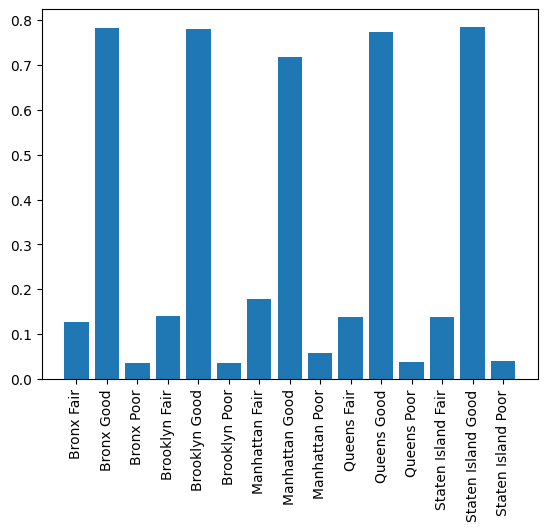

In [135]:
plt.bar(x=health_borough['bor_health'], height=health_borough['percent'])
plt.xticks(rotation=90)
plt.show()

In [136]:
status_borough = trees.groupby(['borough','status'])['tree_id'].count().reset_index(name='count')

status_borough

,borough,status,count
0,Bronx,Alive,77355
1,Bronx,Dead,2409
2,Bronx,Stump,2010
3,Brooklyn,Alive,163244
4,Brooklyn,Dead,3198
5,Brooklyn,Stump,4095
6,Manhattan,Alive,58210
7,Manhattan,Dead,1722
8,Manhattan,Stump,1149
9,Queens,Alive,229871


In [137]:
status_borough = status_borough.merge(
    borough_totals,
    on='borough',
    how='left'
)

status_borough.head(10)

,borough,status,count,borough_total
0,Bronx,Alive,77355,81774
1,Bronx,Dead,2409,81774
2,Bronx,Stump,2010,81774
3,Brooklyn,Alive,163244,170537
4,Brooklyn,Dead,3198,170537
5,Brooklyn,Stump,4095,170537
6,Manhattan,Alive,58210,61081
7,Manhattan,Dead,1722,61081
8,Manhattan,Stump,1149,61081
9,Queens,Alive,229871,242138


In [138]:
status_borough['percent'] = status_borough['count'] / status_borough['borough_total']

status_borough.head()

,borough,status,count,borough_total,percent
0,Bronx,Alive,77355,81774,0.945961
1,Bronx,Dead,2409,81774,0.029459
2,Bronx,Stump,2010,81774,0.024580
3,Brooklyn,Alive,163244,170537,0.957235
4,Brooklyn,Dead,3198,170537,0.018753


In [139]:
status_borough['bor_stat'] = status_borough['borough'] + ' ' + status_borough['status']

status_borough.head()

,borough,status,count,borough_total,percent,bor_stat
0,Bronx,Alive,77355,81774,0.945961,Bronx Alive
1,Bronx,Dead,2409,81774,0.029459,Bronx Dead
2,Bronx,Stump,2010,81774,0.024580,Bronx Stump
3,Brooklyn,Alive,163244,170537,0.957235,Brooklyn Alive
4,Brooklyn,Dead,3198,170537,0.018753,Brooklyn Dead


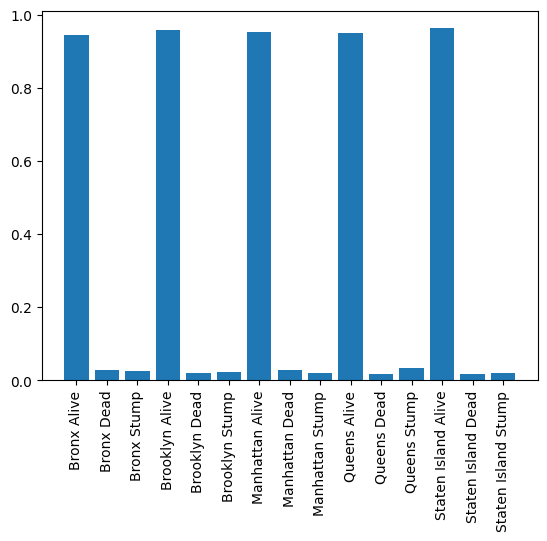

In [140]:
plt.bar(x=status_borough['bor_stat'], height=status_borough['percent'])
plt.xticks(rotation=90)
plt.show()

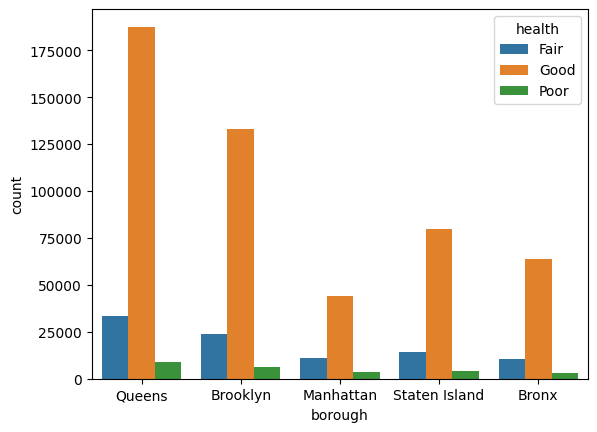

In [141]:
sns.countplot(
    data=trees,
    x='borough',
    hue='health'
)

plt.show()

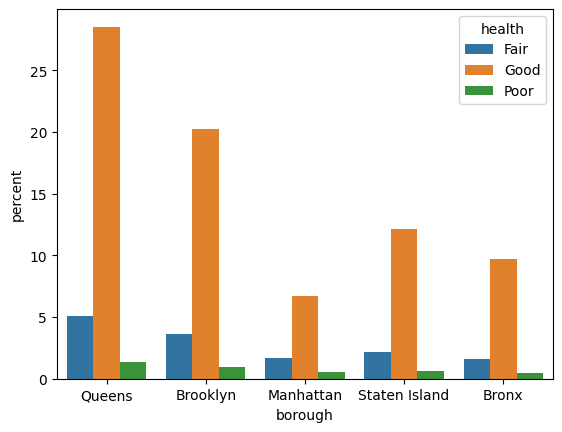

In [142]:
sns.countplot(
    data=trees,
    x='borough',
    hue='health',
    stat='percent'
)

plt.show()

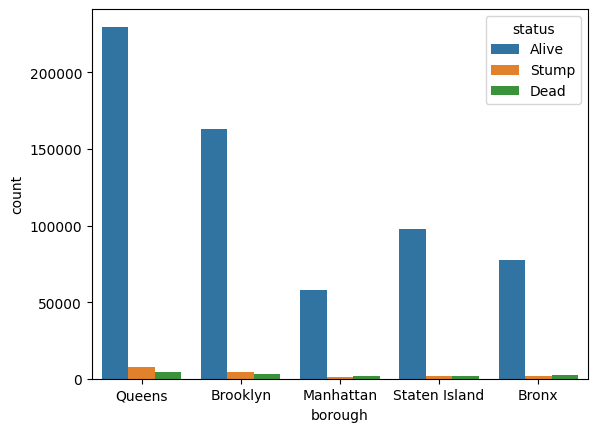

In [143]:
sns.countplot(
    data=trees,
    x='borough',
    hue='status'
)

plt.show()

## EDA on income

In [144]:
income.head()

,zipcode,num_households,median_income,mean_income
0,10451,18140,26048,40836
1,10452,25432,24790,36083
2,10453,26802,23095,33354
3,10454,12790,20210,31533
4,10455,14023,23253,32854


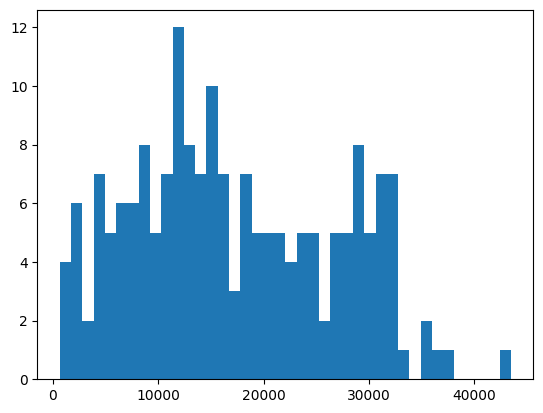

In [145]:
plt.hist(income['num_households'], bins=40)
plt.show()

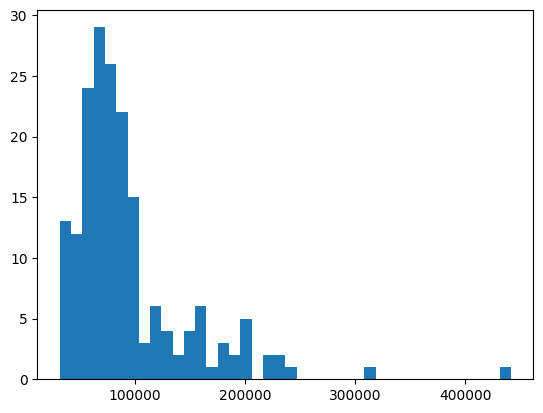

In [ ]:
plt.hist(income['mean_income'], bins=40)
plt.show()

In [ ]:
income[income['mean_income'] > 300000]

,zipcode,num_households,median_income,mean_income
71,10007,2781,250000,441278
133,10282,2439,250000,318142


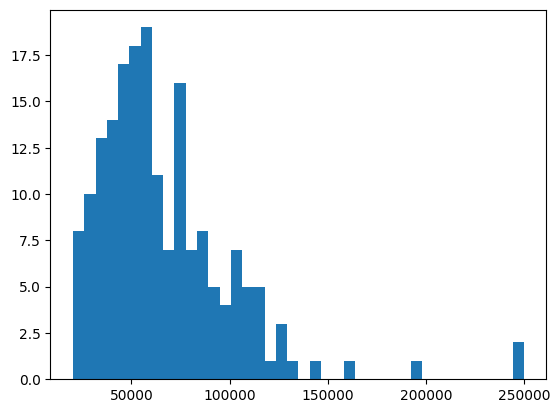

In [ ]:
plt.hist(income['median_income'], bins=40)
plt.show()

In [146]:
income[income['median_income'] > 150000]

,zipcode,num_households,median_income,mean_income
71,10007,2781,250000,441278
105,10069,2850,163750,231265
117,10162,671,193510,216132
133,10282,2439,250000,318142


## Connecting trees to income for analysis

In [147]:
income.head()

,zipcode,num_households,median_income,mean_income
0,10451,18140,26048,40836
1,10452,25432,24790,36083
2,10453,26802,23095,33354
3,10454,12790,20210,31533
4,10455,14023,23253,32854


In [148]:
trees = trees.merge(income, on='zipcode', how='left')
trees.head()

,tree_id,trunk_diam,stump_diam,curb_loc,status,health,spc_latin,spc_common,zipcode,zip_city,borocode,borough,nta,neighborhood,boro_ct,latitude,longitude,num_households,median_income,mean_income
0,180683,3,0,OnCurb,Alive,Fair,Acer rubrum,red maple,11375,Forest Hills,4,Queens,QN17,Forest Hills,4073900,40.723092,-73.844215,32272.0,72414.0,95909.0
1,200540,21,0,OnCurb,Alive,Fair,Quercus palustris,pin oak,11357,Whitestone,4,Queens,QN49,Whitestone,4097300,40.794111,-73.818679,14846.0,73750.0,91915.0
2,204026,3,0,OnCurb,Alive,Good,Gleditsia triacanthos var. inermis,honeylocust,11211,Brooklyn,3,Brooklyn,BK90,East Williamsburg,3044900,40.717581,-73.936608,37381.0,54406.0,84221.0
3,204337,10,0,OnCurb,Alive,Good,Gleditsia triacanthos var. inermis,honeylocust,11211,Brooklyn,3,Brooklyn,BK90,East Williamsburg,3044900,40.713537,-73.934456,37381.0,54406.0,84221.0
4,189565,21,0,OnCurb,Alive,Good,Tilia americana,American linden,11215,Brooklyn,3,Brooklyn,BK37,Park Slope-Gowanus,3016500,40.666778,-73.975979,29182.0,103716.0,144180.0


In [149]:
trees['neighborhood'].value_counts()

neighborhood
Annadale-Huguenot-Prince's Bay-Eltingville                  12527
Great Kills                                                 10431
Bayside-Bayside Hills                                        9391
East New York                                                9107
Rossville-Woodrow                                            8976
New Springville-Bloomfield-Travis                            8203
Charleston-Richmond Valley-Tottenville                       7936
Forest Hills                                                 7446
Whitestone                                                   7366
Georgetown-Marine Park-Bergen Beach-Mill Basin               7175
South Ozone Park                                             7174
Murray Hill                                                  7024
St. Albans                                                   7010
Douglas Manor-Douglaston-Little Neck                         6941
Queens Village                                               67

In [150]:
# Filtering to just alive

trees = trees[trees['status'] == 'Alive']

In [151]:
zips = trees.groupby('zipcode')['tree_id'].count().reset_index(name='count')

zips.head()


,zipcode,count
0,83,522
1,10001,832
2,10002,1813
3,10003,1922
4,10004,89


In [ ]:
# trees[trees['zipcode'] == 83]

In [ ]:
# What is this 83 zipcode?

zip_83 = trees[trees['zipcode'] == 83]

avg_lat = zip_83['latitude'].mean()
avg_long = zip_83['longitude'].mean()

map_83 = Map(center = (avg_lat, avg_long), zoom = 13, min_zoom = 1, max_zoom = 20, 
    basemap=basemaps.OpenStreetMap.Mapnik)

list_zip_83 = list(zip(zip_83['latitude'], zip_83['longitude']))

for lat, lon in list_zip_83:
    marker1 = CircleMarker(location=(lat, lon), color='blue', radius=1)
    map_83.add_layer(marker1)

map_83


Map(center=[np.float64(40.78292086821888), np.float64(-73.96308505509657)], controls=(ZoomControl(options=['po…

Zipcode 83 is the addresses facing Central Park--possibly an error, possibly a way to avoid the park skewing the data for the rest of the affected zipcodes.

Option for further analysis: replace 83 with correct zipcodes

# Looking at top and bottom 10 of median income grouped by zip

In [153]:
zips = zips.merge(income, on='zipcode', how='left')

zips.head()

,zipcode,count,num_households,median_income,mean_income
0,83,522,NaN,NaN,NaN
1,10001,832,11639.0,86801.0,158183.0
2,10002,1813,33348.0,33726.0,61946.0
3,10003,1922,27487.0,98151.0,161692.0
4,10004,89,1574.0,119691.0,177262.0


In [154]:
# Getting average latitude and longitude per grouped by zip code

avg_coord = trees.groupby('zipcode')[['latitude','longitude']].mean().reset_index()
zips = zips.merge(avg_coord, on='zipcode', how='left')
zips.head()

,zipcode,count,num_households,median_income,mean_income,latitude,longitude
0,83,522,NaN,NaN,NaN,40.783337,-73.964127
1,10001,832,11639.0,86801.0,158183.0,40.750276,-73.999084
2,10002,1813,33348.0,33726.0,61946.0,40.716627,-73.988190
3,10003,1922,27487.0,98151.0,161692.0,40.731834,-73.988301
4,10004,89,1574.0,119691.0,177262.0,40.703647,-74.012819


In [155]:
top_10_median = zips.sort_values(by='median_income', ascending=False).head(10)

top_10_median['count'].mean()

np.float64(455.8)

In [156]:
bottom_10_median =zips.sort_values(by='median_income', ascending=True).head(10)

bottom_10_median['count'].mean()

np.float64(2491.8)

In [157]:
bottom_10_median

,zipcode,count,num_households,median_income,mean_income,latitude,longitude
64,10454,1573,12790.0,20210.0,31533.0,40.807674,-73.917281
63,10453,2794,26802.0,23095.0,33354.0,40.852258,-73.911627
70,10460,3007,19776.0,23209.0,35624.0,40.840573,-73.880318
65,10455,1862,14023.0,23253.0,32854.0,40.815187,-73.907825
69,10459,2823,15688.0,23761.0,35964.0,40.825656,-73.894435
66,10456,3632,29255.0,23956.0,35722.0,40.829699,-73.908716
67,10457,3788,23749.0,24750.0,36604.0,40.846704,-73.898448
62,10452,2849,25432.0,24790.0,36083.0,40.837408,-73.922352
61,10451,2098,18140.0,26048.0,40836.0,40.821335,-73.922104
134,11239,492,6362.0,26186.0,34840.0,40.652006,-73.876801


In [159]:
# Mapping top 10 and bottom 10 median income

avg_lat = zips['latitude'].mean()
avg_long = zips['longitude'].mean()

map = Map(center = (avg_lat, avg_long), zoom = 10, min_zoom = 1, max_zoom = 20, 
    basemap=basemaps.OpenStreetMap.Mapnik)

high = list(zip(top_10_median['latitude'], top_10_median['longitude']))

for lat, lon in high:
    marker1 = CircleMarker(location=(lat, lon), color='green', radius=4)
    map.add_layer(marker1)

low = list(zip(bottom_10_median['latitude'], bottom_10_median['longitude']))

for lat, lon in low:
    marker2 = CircleMarker(location=(lat, lon), color='red', radius=4)
    map.add_layer(marker2)

legend = LegendControl(
    legend={'Top 10 Median Income': 'green','Bottom 10 Median Income': 'red'},
    title='Median Income',
       position='topright'
)

map.add_control(legend)

map

Map(center=[np.float64(40.72570950279516), np.float64(-73.91507621912618)], controls=(ZoomControl(options=['po…

In [160]:
print(f"Average number of trees in Top 10 Median Income Zipcodes: {round(top_10_median['count'].mean())}")
print(f"Average number of trees in Bottom 10 Median Income Zipcodes: {round(bottom_10_median['count'].mean())}")

Average number of trees in Top 10 Median Income Zipcodes: 456
Average number of trees in Bottom 10 Median Income Zipcodes: 2492


# Repeating top and bottom 10 mapping for just Manhattan

In [161]:
manhattan = trees[trees['borough'] == 'Manhattan']
manhattan.head()

,tree_id,trunk_diam,stump_diam,curb_loc,status,health,spc_latin,spc_common,zipcode,zip_city,borocode,borough,nta,neighborhood,boro_ct,latitude,longitude,num_households,median_income,mean_income
5,190422,11,0,OnCurb,Alive,Good,Gleditsia triacanthos var. inermis,honeylocust,10023,New York,1,Manhattan,MN14,Lincoln Square,1014500,40.770046,-73.984950,32755.0,111478.0,188600.0
6,190426,11,0,OnCurb,Alive,Good,Gleditsia triacanthos var. inermis,honeylocust,10023,New York,1,Manhattan,MN14,Lincoln Square,1014500,40.770210,-73.985338,32755.0,111478.0,188600.0
7,208649,9,0,OnCurb,Alive,Good,Tilia americana,American linden,10019,New York,1,Manhattan,MN15,Clinton,1012700,40.762724,-73.987297,23146.0,94022.0,144753.0
20,193310,14,0,OnCurb,Alive,Good,Gleditsia triacanthos var. inermis,honeylocust,10021,New York,1,Manhattan,MN40,Upper East Side-Carnegie Hill,1012800,40.772171,-73.960456,23739.0,115076.0,218180.0
21,199760,4,0,OnCurb,Alive,Fair,Quercus phellos,willow oak,10024,New York,1,Manhattan,MN12,Upper West Side,1016300,40.782087,-73.980964,28675.0,113839.0,202005.0


In [162]:
manhattan_zip_list = manhattan['zipcode'].unique().tolist()

manhattan_zips = zips[zips['zipcode'].isin(manhattan_zip_list)]

manhattan_zips.head()

,zipcode,count,num_households,median_income,mean_income,latitude,longitude
0,83,522,NaN,NaN,NaN,40.783337,-73.964127
1,10001,832,11639.0,86801.0,158183.0,40.750276,-73.999084
2,10002,1813,33348.0,33726.0,61946.0,40.716627,-73.988190
3,10003,1922,27487.0,98151.0,161692.0,40.731834,-73.988301
4,10004,89,1574.0,119691.0,177262.0,40.703647,-74.012819


In [163]:
# Getting average latitude and longitude per grouped by zip code

top_10_manhattan = manhattan_zips.sort_values(by='median_income', ascending=False).head(10)

top_10_manhattan['count'].mean()

bottom_10_manhattan = manhattan_zips.sort_values(by='median_income', ascending=True).head(10)

bottom_10_manhattan['count'].mean()

# Mapping top 10 and bottom 10 median income

avg_lat = manhattan_zips['latitude'].mean()
avg_long = manhattan_zips['longitude'].mean()

map = Map(center = (avg_lat, avg_long), zoom = 10, min_zoom = 1, max_zoom = 20, 
    basemap=basemaps.OpenStreetMap.Mapnik)

high = list(zip(top_10_manhattan['latitude'], top_10_manhattan['longitude']))

for lat, lon in high:
    marker1 = CircleMarker(location=(lat, lon), color='green', radius=4)
    map.add_layer(marker1)

low = list(zip(bottom_10_manhattan['latitude'], bottom_10_manhattan['longitude']))

for lat, lon in low:
    marker2 = CircleMarker(location=(lat, lon), color='red', radius=4)
    map.add_layer(marker2)

legend = LegendControl(
    legend={'Top 10 Median Income': 'green','Bottom 10 Median Income': 'red'},
    title='Median Income - Manhattan',
       position='topright'
)

map.add_control(legend)

map

Map(center=[np.float64(40.76593999775309), np.float64(-73.97587272551004)], controls=(ZoomControl(options=['po…

In [164]:
print(f"Average number of trees in Top 10 Median Income Zipcodes: {round(top_10_manhattan['count'].mean())}")
print(f"Average number of trees in Bottom 10 Median Income Zipcodes: {round(bottom_10_manhattan['count'].mean())}")

Average number of trees in Top 10 Median Income Zipcodes: 616
Average number of trees in Bottom 10 Median Income Zipcodes: 1678


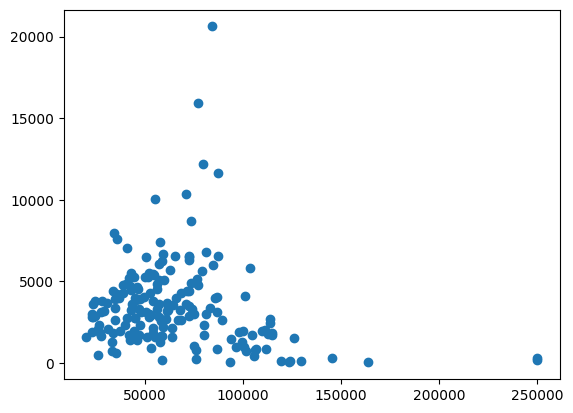

In [165]:
plt.scatter(x=zips['median_income'], y=zips['count'])
plt.show()

In [166]:
zips[zips['count'] == zips['count'].max()]

,zipcode,count,num_households,median_income,mean_income,latitude,longitude
59,10312,20618,21530.0,84584.0,102797.0,40.543009,-74.177807


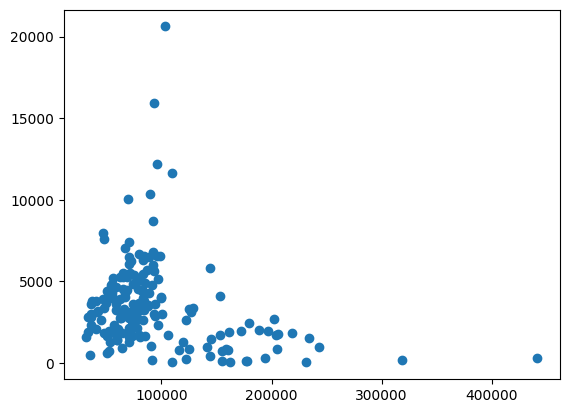

In [167]:
plt.scatter(x=zips['mean_income'], y=zips['count'])
plt.show()

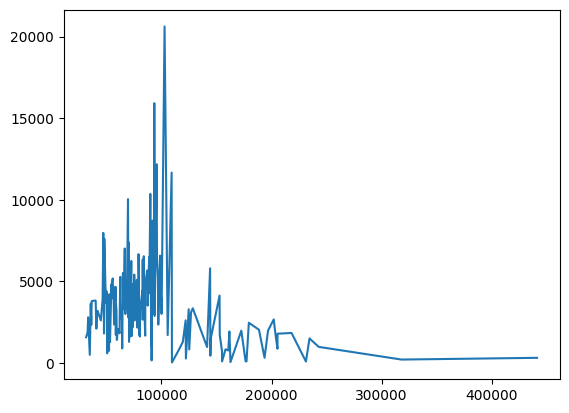

In [168]:
zips_sorted = zips.sort_values(by='mean_income')

plt.plot(zips_sorted['mean_income'], zips_sorted['count'])
plt.show()